### Feature Engineering

Feature Engineering = Process of creating new features or transforming 
existing ones to improve model performance.

Why? "Garbage In, Garbage Out" - Better features = Better models

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Raw data
data = pd.DataFrame({
    'size': [1500, 2000, 2500, 1800, 2200],
    'bedrooms': [2, 3, 4, 3, 3],
    'age': [10, 5, 20, 15, 8],
    'price': [300000, 400000, 500000, 350000, 450000]
})

# Feature Engineering
data['price_per_sqft'] = data['price'] / data['size']
data['room_efficiency'] = data['size'] / data['bedrooms']
data['age_category'] = np.where(data['age'] < 5, 'New', 
                                np.where(data['age'] > 15, 'Old', 'Moderate'))

# Polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(data[['size', 'age']])
poly_df = pd.DataFrame(poly_features, columns=['size', 'age', 'size²', 'size×age', 'age²'])

print("Engineered Features:\n", data.head())
print("\nPolynomial Features:\n", poly_df.head())

Engineered Features:
    size  bedrooms  age   price  price_per_sqft  room_efficiency age_category
0  1500         2   10  300000      200.000000       750.000000     Moderate
1  2000         3    5  400000      200.000000       666.666667     Moderate
2  2500         4   20  500000      200.000000       625.000000          Old
3  1800         3   15  350000      194.444444       600.000000     Moderate
4  2200         3    8  450000      204.545455       733.333333     Moderate

Polynomial Features:
      size   age      size²  size×age   age²
0  1500.0  10.0  2250000.0   15000.0  100.0
1  2000.0   5.0  4000000.0   10000.0   25.0
2  2500.0  20.0  6250000.0   50000.0  400.0
3  1800.0  15.0  3240000.0   27000.0  225.0
4  2200.0   8.0  4840000.0   17600.0   64.0


🏠 Real Estate Example:
- Raw: "House is 2000 sq ft" → Limited info
- Engineered: "Price per sq ft is $200" → More meaningful
- Why? A 2000 sq ft house in NYC vs Kansas have different prices
- Feature: "Location score" captures this context

🔑 Key Insight: Features should encode domain knowledge!

### Train-Test Split

Splitting data into:
- Training Set (70-80%): Used to train the model
- Test Set (20-30%): Used to evaluate performance

Purpose: Assess how well model generalizes to unseen data

In [5]:
from sklearn.model_selection import train_test_split
import numpy as np

X = np.random.randn(1000,10)    #1000 samples, 10 features
y = np.random.randn(1000)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

from sklearn.datasets import make_classification
X,y=make_classification(n_samples=1000,n_features=10,weights=[0.9,0.1],random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Training size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Training class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Training size: 800, Test size: 200
Training class distribution: [718  82]
Test class distribution: [179  21]


📚 Student Exam Analogy:
- Training = Practice questions (70%)
- Test = Exam questions (30%)
- If you study exam questions → Score high but learned nothing
- Model must learn patterns, not memorize answers!

### Overfitting

Model learns training data TOO WELL, including noise and random fluctuations.
Performs great on training but poorly on new data.

Symptoms: 
- Training accuracy: 99%
- Test accuracy: 60%

📉 Overfitting Example:

- Training: Model learns that all dogs have 4 legs and wag tails
- Test: Sees a dog with 3 legs → "This is not a dog!"
- ⬆️ Overfitting: Complex model with many parameters
- ⬇️ Underfitting: Simple model that misses patterns

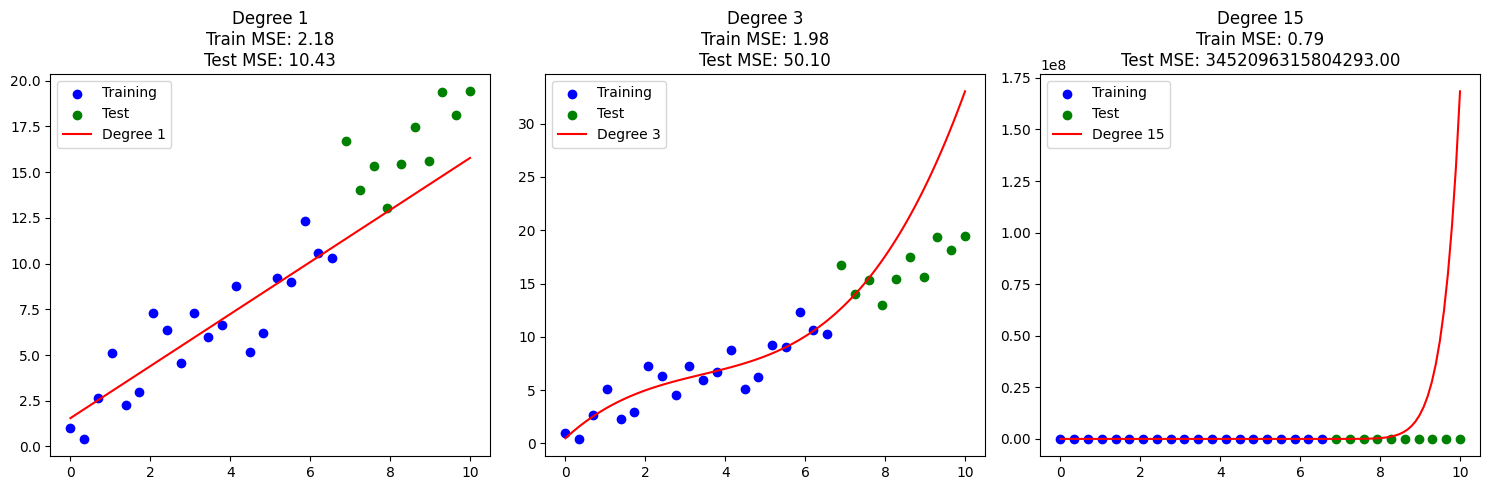

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 10, 30).reshape(-1, 1)
y = 2 * X.ravel() + np.random.normal(0, 2, 30)

# Create train-test split
X_train, X_test = X[:20], X[20:]
y_train, y_test = y[:20], y[20:]

# Compare different polynomial degrees
degrees = [1, 3, 15]  # Simple, Moderate, Overfit
plt.figure(figsize=(15, 5))

for i, degree in enumerate(degrees):
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_poly_train, y_train)
    
    train_pred = model.predict(X_poly_train)
    test_pred = model.predict(X_poly_test)
    
    # Plot
    plt.subplot(1, 3, i+1)
    plt.scatter(X_train, y_train, color='blue', label='Training')
    plt.scatter(X_test, y_test, color='green', label='Test')
    X_plot = np.linspace(0, 10, 100).reshape(-1, 1)
    X_plot_poly = poly.transform(X_plot)
    plt.plot(X_plot, model.predict(X_plot_poly), color='red', label=f'Degree {degree}')
    plt.title(f'Degree {degree}\nTrain MSE: {mean_squared_error(y_train, train_pred):.2f}\n'
              f'Test MSE: {mean_squared_error(y_test, test_pred):.2f}')
    plt.legend()

plt.tight_layout()
plt.show()

🎯 Archery Analogy:
- Overfitting = Aiming perfectly at practice target (training)
- But shooting poorly at competition target (test)
- You've memorized the practice range conditions
- Good model = Generalizes to new ranges!

### UNDERFITTING

- Model is too simple to capture underlying patterns in data.
- Performs poorly on BOTH training and test data.

Symptoms:

- Training accuracy: 60%
- Test accuracy: 55%

📈 Underfitting Example:
Trying to fit a straight line to complex data:
- True pattern: y = x² + noise
- Model: y = mx + b (too simple)

Result: Can't capture the curve → High bias

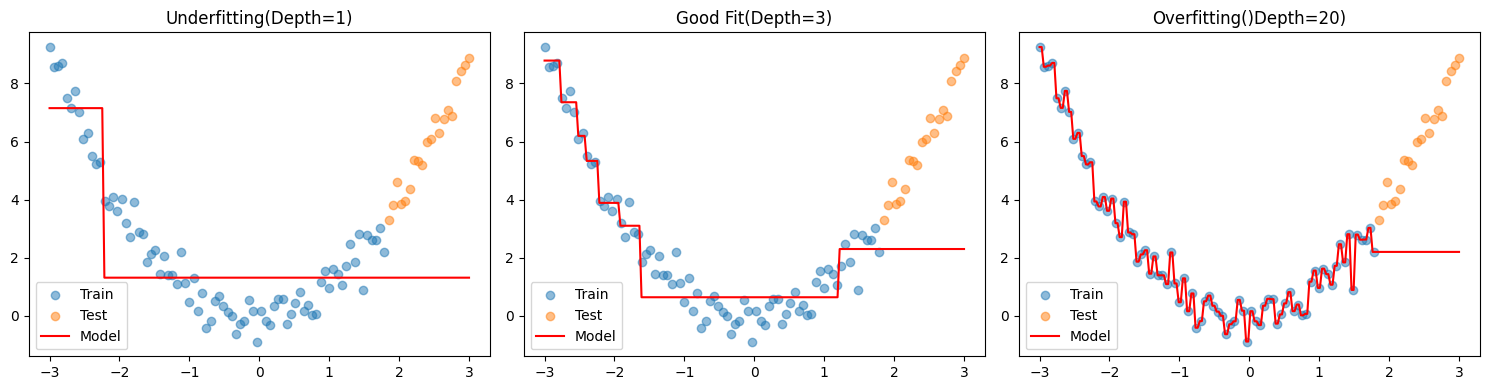

In [11]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Generate non-linear data
np.random.seed(42)
x = np.linspace(-3, 3, 100).reshape(-1, 1)
y = x.ravel()**2+np.random.normal(0,0.5,100)

x_train,x_test=x[:80],x[80:]
y_train,y_test=y[:80],y[80:]

underfit_model=DecisionTreeRegressor(max_depth=1)
underfit_model.fit(x_train,y_train)

good_model=DecisionTreeRegressor(max_depth=3)
good_model.fit(x_train,y_train)

overfit_model=DecisionTreeRegressor(max_depth=20)
overfit_model.fit(x_train,y_train)

import matplotlib.pyplot as plt
plt.figure(figsize=(15,4))

for i,(model,title) in enumerate([
    (underfit_model,'Underfitting(Depth=1)'),
    (good_model,'Good Fit(Depth=3)'),
    (overfit_model,'Overfitting()Depth=20)')
]):
    plt.subplot(1,3,i+1)
    plt.scatter(x_train,y_train,alpha=0.5,label='Train')
    plt.scatter(x_test,y_test,alpha=0.5,label='Test')
    x_grid = np.linspace(-3, 3, 200).reshape(-1, 1)
    plt.plot(x_grid, model.predict(x_grid), 'r-', label='Model')
    plt.title(title)
    plt.legend()

plt.tight_layout()
plt.show()

🧮 Math Teacher Analogy:
- Underfitting = Teaching addition only (bias)
- Data includes multiplication, division
- Students fail because they can't handle the complexity
- Need richer model complexity!

### Cross Validation

- Technique to assess model performance by splitting data into k folds.
- Each fold gets turn as validation while others train.
- Most common: k-fold cross-validation (k=5 or 10)

### 5-Fold Cross-Validation:
- Fold 1: [Train] [Train] [Train] [Train] [Valid]
- Fold 2: [Train] [Train] [Train] [Valid] [Train]
- Fold 3: [Train] [Train] [Valid] [Train] [Train]
- Fold 4: [Train] [Valid] [Train] [Train] [Train]
- Fold 5: [Valid] [Train] [Train] [Train] [Train]

Average Performance = Mean of all 5 validation scores

In [12]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
import numpy as np

# Load data
iris = load_iris()
X, y = iris.data, iris.target

# Simple cross-validation
model = RandomForestClassifier(n_estimators=100)
scores = cross_val_score(model, X, y, cv=5)
print(f"5-Fold CV Scores: {scores}")
print(f"Mean CV Score: {scores.mean():.3f} (+/- {scores.std()*2:.3f})")

# Custom cross-validation with shuffling
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kf)
print(f"Shuffled 5-Fold CV Scores: {scores}")

# Stratified K-Fold (for classification)
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=skf)
print(f"Stratified CV Scores: {scores}")

# Practical: Model selection with CV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(),
    'Random Forest': RandomForestClassifier()
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name}: {scores.mean():.3f} (+/- {scores.std():.3f})")

5-Fold CV Scores: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Mean CV Score: 0.967 (+/- 0.042)
Shuffled 5-Fold CV Scores: [1.         0.96666667 0.93333333 0.93333333 0.96666667]
Stratified CV Scores: [1.         0.96666667 0.93333333 0.96666667 0.9       ]
Logistic Regression: 0.973 (+/- 0.025)
SVM: 0.967 (+/- 0.021)
Random Forest: 0.967 (+/- 0.021)


🎯 Job Interview Analogy:
- 1-fold = One interview (maybe lucky or unlucky)
- k-fold = Multiple interviews with different panelists
- Average performance = True competence
- More robust assessment!

### Bias-Variance TradeOff

- Bias: Error from oversimplifying assumptions (underfitting)
- Variance: Error from sensitivity to small fluctuations (overfitting)
- Tradeoff: Cannot minimize both simultaneously

Total Error = Bias² + Variance + Irreducible Error

Simple Model (High Bias, Low Variance):

- Misses patterns → High Bias
- Consistent predictions → Low Variance

Complex Model (Low Bias, High Variance):

- Captures patterns → Low Bias
- Sensitive to noise → High Variance

Optimal Model = Balance between Bias and Variance

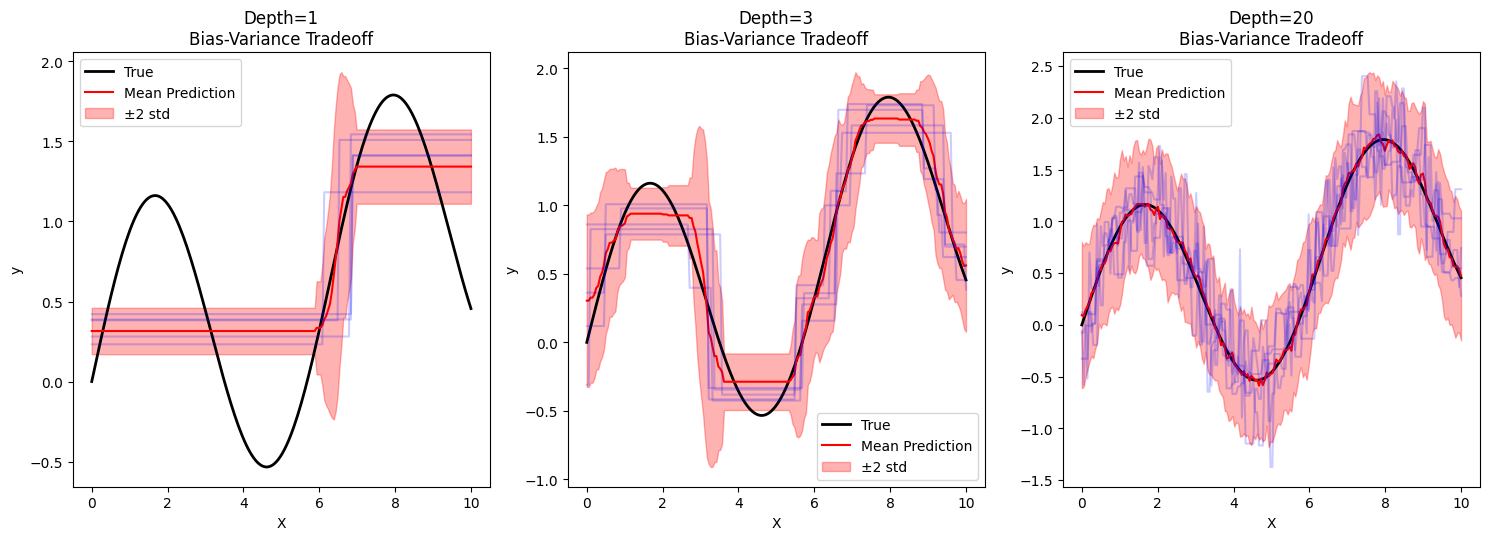

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Simulate bias-variance tradeoff
np.random.seed(42)
n_samples = 100
n_repeats = 50

# Generate data with noise
X = np.random.uniform(0, 10, n_samples)
X_grid = np.linspace(0, 10, 200)

def true_function(X):
    return np.sin(X) + 0.1 * X

def generate_data():
    X = np.random.uniform(0, 10, n_samples)
    y = true_function(X) + np.random.normal(0, 0.3, n_samples)
    return X, y

# Compare models
depths = [1, 3, 20]
plt.figure(figsize=(15, 10))

for depth in depths:
    plt.subplot(2, 3, depths.index(depth)+1)
    
    # Fit many models
    all_predictions = []
    for _ in range(n_repeats):
        X_train, y_train = generate_data()
        tree = DecisionTreeRegressor(max_depth=depth)
        tree.fit(X_train.reshape(-1, 1), y_train)
        y_pred = tree.predict(X_grid.reshape(-1, 1))
        all_predictions.append(y_pred)
    
    all_predictions = np.array(all_predictions)
    mean_pred = all_predictions.mean(axis=0)
    std_pred = all_predictions.std(axis=0)
    
    # Plot
    plt.plot(X_grid, true_function(X_grid), 'k-', label='True', linewidth=2)
    plt.plot(X_grid, mean_pred, 'r-', label='Mean Prediction')
    plt.fill_between(X_grid, mean_pred - 2*std_pred, mean_pred + 2*std_pred,
                     alpha=0.3, color='red', label='±2 std')
    
    # Display sample predictions
    for i in range(5):
        plt.plot(X_grid, all_predictions[i], 'b-', alpha=0.2)
    
    plt.title(f'Depth={depth}\nBias-Variance Tradeoff')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()

plt.tight_layout()
plt.show()

🎯 Target Practice Analogy:
- High Bias = Shots consistently miss center (systematic error)
- High Variance = Shots spread out randomly (inconsistent)
- Good shooter = Low bias (accurate) AND low variance (precise)
- But improving one often worsens the other!

#### Gradient Descent

- Optimization algorithm to find minimum of function.
- Iteratively adjusts parameters in direction of steepest descent.

Algorithm:
1. Initialize parameters (weights)
2. Compute gradient (derivative) of loss function
3. Update parameters: θ = θ - α × ∇J(θ)
4. Repeat until convergence

📝 Simple Example: Minimize f(x) = x²

- Step 1: Start at x = 5
- Step 2: Gradient = df/dx = 2x = 10
- Step 3: Update: x = 5 - 0.1 × 10 = 4
- Step 4: New gradient = 8
- Step 5: Update: x = 4 - 0.1 × 8 = 3.2
- ...continues until x ≈ 0

Learning Rate (α) = Step size
- Too large → Diverges
- Too small → Slow convergence

Key insight: The update rule always moves parameters in the negative gradient direction, scaled by the learning rate, to minimize the loss function!

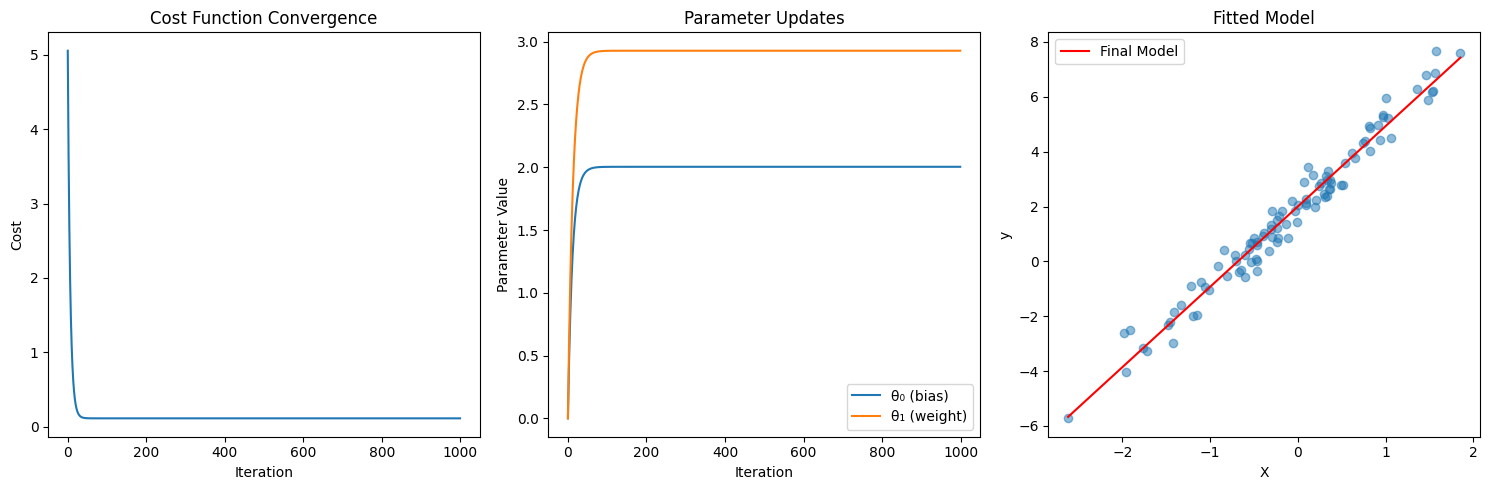

True coefficients: θ₀=2, θ₁=3
Learned coefficients: θ₀=2.004, θ₁=2.928


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Implement gradient descent for linear regression
def gradient_descent(X, y, learning_rate=0.01, n_iterations=1000):
    m = len(y)
    theta = np.zeros(X.shape[1])
    cost_history = []
    theta_history = []
    
    for i in range(n_iterations):
        # Prediction
        y_pred = X.dot(theta)
        
        # Cost (MSE)
        cost = (1/(2*m)) * np.sum((y_pred - y)**2)
        cost_history.append(cost)
        theta_history.append(theta.copy())
        
        # Gradient
        gradient = (1/m) * X.T.dot(y_pred - y)
        
        # Update
        theta = theta - learning_rate * gradient
        
    return theta, cost_history, theta_history

# Generate data
np.random.seed(42)
X = np.random.randn(100, 1)
y = 3 * X.ravel() + 2 + np.random.normal(0, 0.5, 100)
X_b = np.c_[np.ones((100, 1)), X]  # Add bias term

# Run gradient descent
theta, cost_history, theta_history = gradient_descent(X_b, y, learning_rate=0.1)

# Visualize convergence
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Cost function convergence
axes[0].plot(cost_history)
axes[0].set_title('Cost Function Convergence')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost')

# Parameter trajectory
theta_history = np.array(theta_history)
axes[1].plot(theta_history[:, 0], label='θ₀ (bias)')
axes[1].plot(theta_history[:, 1], label='θ₁ (weight)')
axes[1].set_title('Parameter Updates')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Parameter Value')
axes[1].legend()

# Final prediction
axes[2].scatter(X, y, alpha=0.5)
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_plot_b = np.c_[np.ones((100, 1)), X_plot]
y_plot = X_plot_b.dot(theta)
axes[2].plot(X_plot, y_plot, 'r-', label='Final Model')
axes[2].set_title('Fitted Model')
axes[2].set_xlabel('X')
axes[2].set_ylabel('y')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"True coefficients: θ₀=2, θ₁=3")
print(f"Learned coefficients: θ₀={theta[0]:.3f}, θ₁={theta[1]:.3f}")

⛰️ Mountain Descent Analogy:
- You're in fog on mountain, want to reach valley
- Feel slope beneath feet → Which direction is downhill?
- Take small steps downhill
- Repeat until you reach valley (minimum)
- Learning rate = Size of your steps